# Advanced radiation and remote sensing


Manfred Brath, Oliver Lemke

## Exercise 4: Jacobian and opacity rule

In [1]:
%matplotlib widget

import os
import matplotlib.pyplot as plt
import numpy as np
from pyarts import xml
from jacobian import (calc_jacobians, plot_brightness_temperature,
                             plot_jacobian, plot_opacity, plot_opacity_profile,
                             argclosest)

os.makedirs("plots", exist_ok=True)

### 1)
Run the next cells to calculate the brightness temperature spectrum in   
nadir direction and the zenith opacity around the $183\,\text{GHz}$ line  
of water vapor for a midlatitude summer atmosphere. Answer following  
question:

* Are there window regions?

The atmospheric temperature profile for the calculation was:

|**Pressure** $\left[\text{hPa}\right]$|**Temperature** $\left[\text{K}\right]$ | **Altitude** $\left[\text{km}\right]$
|---    |---    |---
|1013.0 | 294.2 | 0
|902.0 | 289.7 | 1
|802.0 | 285.2 | 2
|710.0 | 279.2 | 3
|628.0 | 273.2 | 4
|554.0 | 267.2 | 5
|487.0 | 261.2 | 6
|426.0 | 254.7 | 7
|372.0 | 248.2 | 8
|324.0 | 241.7 | 9
|281.0 | 235.3 | 10
|243.0 | 228.8 | 11
|209.0 | 222.3 | 12
|179.0 | 215.8 | 13
|153.0 | 215.7 | 14
|130.0 | 215.7 | 15
|111.0 | 215.7 | 16
|95.0 | 215.7 | 17
|81.2 | 216.8 | 18
|69.5 | 217.9 | 19
|59.5 | 219.2 | 20

Consider the table and answer following questions:

* From which altitude does the radiation at the peak of the line ($\approx183\,\text{GHz}$)  
originate? 

* From which altitude does the radiation at the wing ($150\,\text{GHz}$) originate? 


In [2]:
# Calculate Jacobians (ARTS)
jacobian_quantity = "H2O"
calc_jacobians(jacobian_quantity=jacobian_quantity)

# read in everything
freq = np.array(xml.load("results/f_grid.xml"))
tau = np.array(xml.load("results/optical_thickness.xml"))
bt = np.array(xml.load("results/y.xml"))
jac = np.array(xml.load("results/jacobian.xml"))
alt = np.array(xml.load("results/z_field.xml")).ravel()
jac /= np.gradient(alt / 1000)  # normalize by layer thickness in km

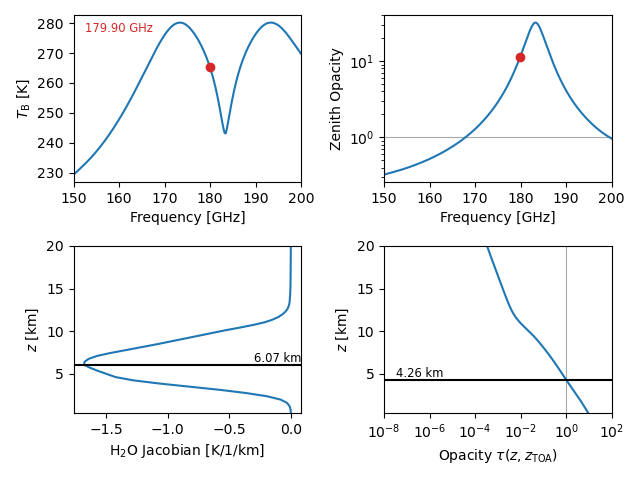

In [3]:
# select frequency
highlight_frequency = 180e9  # Hz

if highlight_frequency is None:
    fig, (ax0, ax1) = plt.subplots(ncols=2)
    plot_brightness_temperature(freq, bt, ax=ax0)
    plot_opacity(freq, tau, ax=ax1)
    freq_ind = None
else:
    fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(2, 2)
    plot_brightness_temperature(freq, bt, where=highlight_frequency, ax=ax0)
    plot_opacity(freq, tau, where=highlight_frequency, ax=ax1)
    freq_ind = argclosest(freq, highlight_frequency)
    plot_jacobian(
        alt, jac[freq_ind, :], jacobian_quantity=jacobian_quantity, ax=ax2
    )
    plot_opacity_profile(alt, tau[:, freq_ind], ax=ax3)

fig.tight_layout()
fig.savefig(f"plots/jacobians-{freq_ind}.pdf")

### 2)
Change the variable `highlight_frequency` from `None` to any desired  
frequency in $[\text{Hz}]$ within the range of the brightness temperature spectrum  
of task 1 and rerun previous cell. This will calculate the water vapor Jacobian and  
the opacity $\tau$ between the top of the atmosphere $z_{TOA}$ and altitude $z$ for the  
selected frequency. Additionally, a circle marks the selected frequency in the plot  
of the brightness temperature spectrum and in the plot of the zenith opacity.  

Write down the altitude of the Jacobian peak and the altitude where the  
opacity reaches 1 for some different frequencies and answer following  
questions:

* Why are the altitude where the opacity reaches 1 and the altitude of  
the Jacobian peak not exactly the same?
* Why are the Jacobians sometimes positive and sometimes negative?